In [1]:
!pip install deepxde

Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



2D Helmholtz Equation - Physics-Informed Neural Network Solver

Problem Parameters:
  Domain: [-1, 1] × [-1, 1]
  PDE: ∇²u + k²u = 2
  BC: u = 0 on boundary (hard constraint)
  Wave number k²: 1.0

Training PINN...
Compiling model...
'compile' took 0.227316 s

Training model...

Step      Train loss    Test loss     Test metric
0         [5.46e+00]    [5.41e+00]    []  
500       [2.22e-01]    [7.64e-02]    []  
1000      [1.78e-01]    [5.48e-02]    []  
1500      [1.43e-01]    [3.52e-02]    []  
2000      [7.76e-02]    [1.55e-02]    []  
2500      [5.54e-02]    [1.04e-02]    []  
3000      [3.94e-02]    [4.22e-03]    []  
3500      [3.24e-02]    [3.09e-03]    []  
4000      [2.55e-02]    [1.84e-03]    []  
4500      [1.96e-02]    [1.67e-03]    []  
5000      [1.68e-02]    [1.76e-03]    []  

Best model at step 5000:
  train loss: 1.68e-02
  test loss: 1.76e-03
  test metric: []

'train' took 6898.778579 s

Training completed!

Evaluating on 31×31 grid...

Evaluation Metrics:
---------

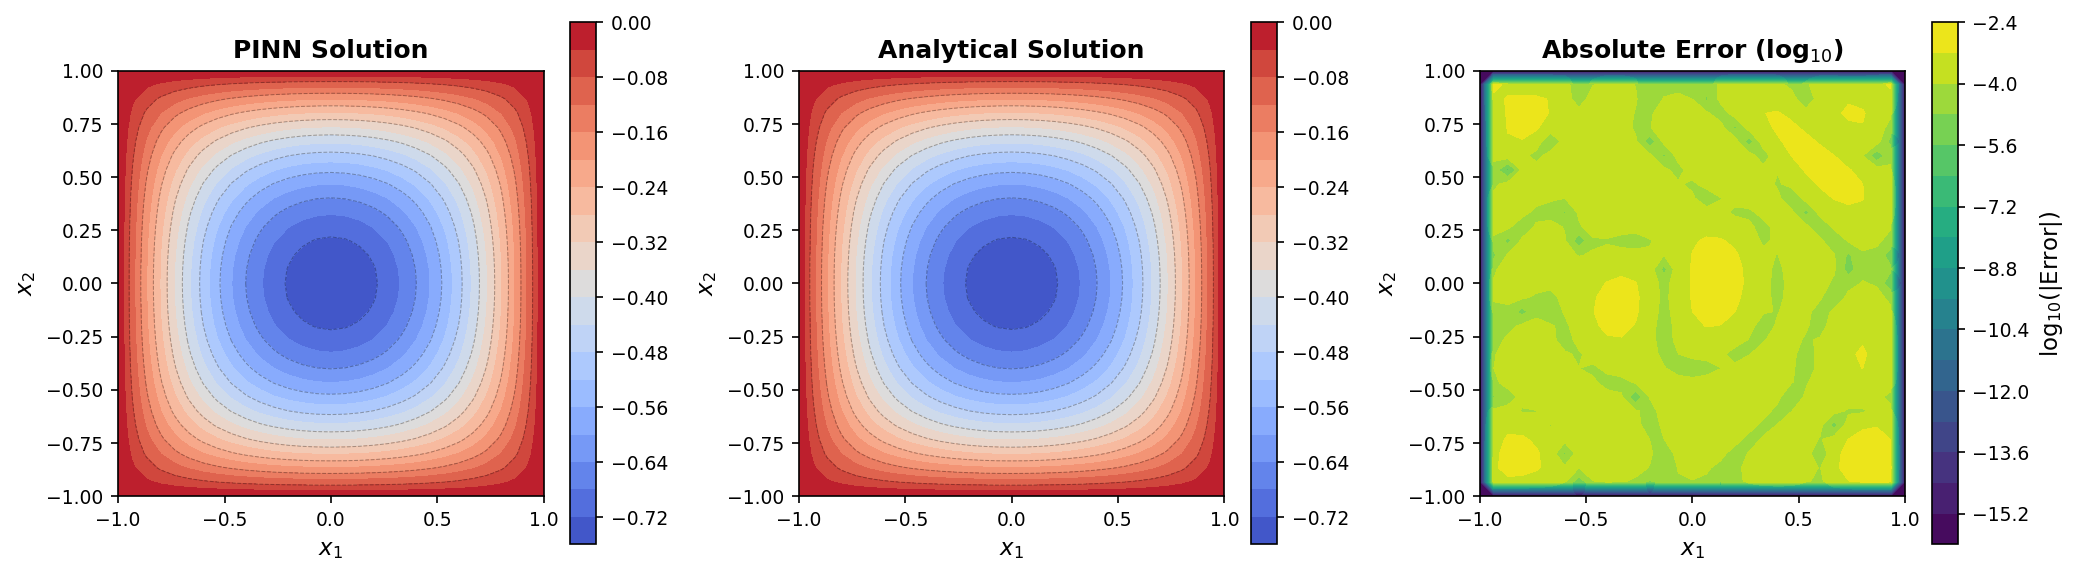


Visualization complete!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import deepxde as dde
from typing import Dict, Tuple, Optional, List

np.random.seed(42)
dde.config.set_random_seed(42)

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
})
plt.rcParams['text.usetex'] = False

cmap_diverging = 'coolwarm'  # for solution
cmap_uncertainty = 'viridis'  # for error/uncertainty


# ----------------------------
# Problem definition
# ----------------------------
def make_pinn_solver(k_squared=1.0, num_domain=500, num_boundary=100, num_test=200):
    """
    Solve (u_xx + u_yy + k^2 u) = 2 on [-1,1]^2 with u=0 on boundary using DeepXDE.
    Minimal configuration for memory-constrained environments.
    """
    # Geometry
    geom = dde.geometry.Rectangle(xmin=[-1.0, -1.0], xmax=[1.0, 1.0])

    # PDE residual: u_xx + u_yy + k^2 u - 2 = 0
    def pde(x, y):
        u_xx = dde.grad.hessian(y, x, i=0, j=0)
        u_yy = dde.grad.hessian(y, x, i=1, j=1)
        # backend-agnostic constant forcing: 2 + 0*x
        f = 2.0 + 0.0 * x[:, 0:1]
        return u_xx + u_yy + k_squared * y - f

    # Hard Dirichlet BC via output transform: (1-x^2)(1-y^2) * NN(x,y)
    def output_transform(x, y):
        factor = (1.0 - x[:, 0:1] ** 2) * (1.0 - x[:, 1:2] ** 2)
        return factor * y

    data = dde.data.PDE(
        geom,
        pde,
        bcs=[],  # no soft BC; hard BC handled by transform
        num_domain=num_domain,
        num_boundary=num_boundary,
        num_test=num_test,
    )

    # Minimal network for memory-constrained environments
    net = dde.nn.FNN(
        [2] + [32, 32] + [1],
        "tanh",  # tanh often uses less memory than sin
        "Glorot uniform",
    )
    net.apply_output_transform(output_transform)

    model = dde.Model(data, net)

    # Train with Adam only (skip L-BFGS to save memory)
    model.compile("adam", lr=1e-3)
    losshistory, train_state = model.train(iterations=5000, display_every=500)

    # Optional: L-BFGS refinement (uncomment if memory allows)
    # dde.optimizers.set_LBFGS_options(maxiter=5000)
    # model.compile("L-BFGS-B")
    # losshistory, train_state = model.train()

    return model, (losshistory, train_state)


# ----------------------------
# Analytical solution (truncated Fourier series)
# ----------------------------
def analytical_constant_source(X, Y, k_squared=1.0, M=101, N=101):
    """
    Approximate analytic solution of (Δ + k^2) u = 2 on (-1,1)^2,
    u = 0 on the boundary, using a truncated sine-sine series.
    Only odd m,n are included.
    """
    xi = (X + 1.0) / 2.0
    eta = (Y + 1.0) / 2.0
    dtype = complex if np.iscomplexobj(k_squared) else float
    u = np.zeros_like(X, dtype=dtype)

    for m in range(1, M, 2):
        for n in range(1, N, 2):
            lam = (np.pi * m / 2) ** 2 + (np.pi * n / 2) ** 2
            denom = -lam + k_squared
            coeff = 32.0 / (np.pi ** 2 * m * n * denom)
            u += coeff * np.sin(np.pi * m * xi) * np.sin(np.pi * n * eta)

    return u


# ----------------------------
# Evaluation on grid
# ----------------------------
def eval_on_grid(model, k_squared=1.0, nx=101, ny=101):
    """Evaluate PINN on a regular grid and compute metrics."""
    x = np.linspace(-1, 1, nx)
    y = np.linspace(-1, 1, ny)
    X, Y = np.meshgrid(x, y, indexing="ij")
    pts = np.hstack([X.reshape(-1, 1), Y.reshape(-1, 1)])

    u_pred = model.predict(pts).reshape(nx, ny)
    u_true = analytical_constant_source(X, Y, k_squared=k_squared, M=101, N=101)
    u_true_real = np.real(u_true)

    rel_l2 = np.linalg.norm(u_pred - u_true_real) / np.linalg.norm(u_true_real)
    max_err = np.max(np.abs(u_pred - u_true_real))
    rmse = np.sqrt(np.mean((u_pred - u_true_real) ** 2))
    mae = np.mean(np.abs(u_pred - u_true_real))
    mse = np.mean((u_pred - u_true_real) ** 2)

    metrics = {
        "mse": mse,
        "relative_l2": rel_l2,
        "max_error": max_err,
        "rmse": rmse,
        "mae": mae,
    }

    return metrics, (X, Y, u_pred, u_true_real)


# ----------------------------
# Visualization (matching FDM style)
# ----------------------------
def plot_solution(
    X: np.ndarray,
    Y: np.ndarray,
    u_pinn: np.ndarray,
    u_analytical: np.ndarray,
    save_path: Optional[str] = None,
    show_plot: bool = True
) -> List[plt.Figure]:
    """
    Plot the PINN solution, analytical solution, and error.
    Simplified version with contour plots only to save memory.
    """
    error = np.abs(u_pinn - u_analytical)
    figures = []

    # Combined figure with 3 subplots (memory efficient)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # 1. PINN Solution
    c1 = axes[0].contourf(X, Y, np.real(u_pinn), levels=20, cmap=cmap_diverging)
    axes[0].contour(X, Y, np.real(u_pinn), levels=10, colors="black", linewidths=0.5, alpha=0.3)
    axes[0].set_xlabel("$x_1$", fontsize=11)
    axes[0].set_ylabel("$x_2$", fontsize=11)
    axes[0].set_title("PINN Solution", fontsize=12, fontweight='bold')
    axes[0].set_aspect("equal")
    fig.colorbar(c1, ax=axes[0])

    # 2. Analytical Solution
    c2 = axes[1].contourf(X, Y, np.real(u_analytical), levels=20, cmap=cmap_diverging)
    axes[1].contour(X, Y, np.real(u_analytical), levels=10, colors="black", linewidths=0.5, alpha=0.3)
    axes[1].set_xlabel("$x_1$", fontsize=11)
    axes[1].set_ylabel("$x_2$", fontsize=11)
    axes[1].set_title("Analytical Solution", fontsize=12, fontweight='bold')
    axes[1].set_aspect("equal")
    fig.colorbar(c2, ax=axes[1])

    # 3. Error (log scale)
    error_log = np.log10(error + 1e-16)
    c3 = axes[2].contourf(X, Y, error_log, levels=20, cmap=cmap_uncertainty)
    axes[2].set_xlabel("$x_1$", fontsize=11)
    axes[2].set_ylabel("$x_2$", fontsize=11)
    axes[2].set_title("Absolute Error (log$_{10}$)", fontsize=12, fontweight='bold')
    axes[2].set_aspect("equal")
    fig.colorbar(c3, ax=axes[2], label="log$_{10}$(|Error|)")

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    figures.append(fig)

    if show_plot:
        plt.show()

    return figures


def plot_training_history(losshistory, save_path: Optional[str] = None, show_plot: bool = True):
    """Plot training loss history."""
    fig, ax = plt.subplots(figsize=(10, 6))

    steps = losshistory.steps
    loss_train = np.sum(losshistory.loss_train, axis=1)

    ax.semilogy(steps, loss_train, 'b-', linewidth=1.5, label='Training Loss')

    if losshistory.loss_test is not None and len(losshistory.loss_test) > 0:
        loss_test = np.sum(losshistory.loss_test, axis=1)
        ax.semilogy(steps, loss_test, 'r--', linewidth=1.5, label='Test Loss')

    ax.set_xlabel("Training Steps", fontsize=11)
    ax.set_ylabel("Loss", fontsize=11)
    ax.set_title("PINN Training History", fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='gray')
    ax.grid(True, alpha=0.3, which="both", linestyle='--', linewidth=0.5)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show_plot:
        plt.show()

    return fig


# ----------------------------
# Main
# ----------------------------
def main():
    """Main function to demonstrate the PINN solver for 2D Helmholtz equation."""
    print("=" * 70)
    print("2D Helmholtz Equation - Physics-Informed Neural Network Solver")
    print("=" * 70)

    k2 = 1.0

    print("\nProblem Parameters:")
    print(f"  Domain: [-1, 1] × [-1, 1]")
    print(f"  PDE: ∇²u + k²u = 2")
    print(f"  BC: u = 0 on boundary (hard constraint)")
    print(f"  Wave number k²: {k2}")

    print("\nTraining PINN...")
    model, (losshistory, train_state) = make_pinn_solver(k_squared=k2)
    print("Training completed!")

    # Evaluate on grid
    print("\nEvaluating on 31×31 grid...")
    metrics, (X, Y, u_pinn, u_analytical) = eval_on_grid(model, k_squared=k2, nx=31, ny=31)

    print("\nEvaluation Metrics:")
    print("-" * 40)
    for name, value in metrics.items():
        print(f"  {name.upper():15s}: {value:.6e}")

    print(f"\n  Solution range: [{np.min(u_pinn):.4f}, {np.max(u_pinn):.4f}]")

    # Skip training history plot to save memory
    # print("\nGenerating training history plot...")
    # plot_training_history(losshistory, save_path="pinn_training_history.png", show_plot=True)

    # Plot solution comparison (reduced set of plots to save memory)
    print("\nGenerating solution visualization plots...")
    plot_solution(X, Y, u_pinn, u_analytical, save_path=None, show_plot=True)

    print("\n" + "=" * 70)
    print("Visualization complete!")
    print("=" * 70)

    return model, metrics


if __name__ == "__main__":
    model, metrics = main()